## 1

#### 1. Градиент $\nabla f(X_k)$

Данная функция:
$$
f(X) = \frac{1}{2} \| X - Y \|_F^2
$$

Норма Фробенисуса:
$$
\| A \|_F^2 = \sum_{i=1}^n \sum_{j=1}^n A_{ij}^2
$$

Тогда
$$
f(X) = \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n (X_{ij} - Y_{ij})^2
$$

$$
\frac{\partial f(X)}{\partial X_{ij}} = X_{ij} - Y_{ij}
$$

$$
\nabla f(X) = X - Y
$$

$$
\nabla f(X_k) = X_k - Y
$$

#### 2. Решение шага LMO: $\min_{S \in B_n} \langle \nabla f(X_k), S \rangle$

Хотим решить
$$
S_k = \arg\min_{S \in B_n} \langle \nabla f(X_k), S \rangle
$$
$$
S_k = \arg\min_{S \in B_n} \langle X_k - Y, S \rangle
$$

Скалярное произведение двух матриц:
$$
\langle A, B \rangle = \sum_{i=1}^n \sum_{j=1}^n A_{ij} B_{ij}
$$

Таким образом минимизируем:
$$
\sum_{i=1}^n \sum_{j=1}^n (X_k - Y)_{ij} S_{ij}
$$
по всем $S \in B_n$.

Любая дважды стохастическая матрица является выпуклой комбинацией перестановочных матриц, такт что минимум линейной функции на $B_n$ достигается в крайней точке — в перестановочной матрице.

То есть $S_k$ будет перестановочной матрицей.

Минимизация $\langle C, S \rangle$ по перестановочным матрицам $S$ (где $C = X_k - Y$) эквивалентна задаче lin assignment, цель — найти взаимно однозначное назначение (перестановку), минимизирующее суммарную стоимость.

##### Алгоритм решения LMO

Венгерский алгоритм решает задачу за $O(n^3)$ времени.
1. Построить матрицу стоимостей $C = X_k - Y$.
2. Найти оптимальную перестановку $\pi^*$, минимизирующую $\sum_{i=1}^n C_{i,\pi(i)}$.
3. Построить перестановочную матрицу $S_k$ из $\pi^*$:
$$
(S_k)_{i,j} =
\begin{cases}
1, & \text{если } j = \pi^*(i), \\
0, & \text{иначе}.
\end{cases}
$$


## 2

In [3]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

def project_to_birkhoff_frank_wolfe(Y, max_iter=100, tol=1e-6):
    """
    Projects matrix Y onto the Birkhoff polytope using the Frank-Wolfe algorithm.

    Args:
        Y (np.ndarray): The matrix to project.
        max_iter (int): Maximum number of iterations.
        tol (float): Tolerance for convergence (change in objective value).

    Returns:
        np.ndarray: The projection of Y onto the Birkhoff polytope.
        list: History of objective function values.
    """
    n = Y.shape[0]
    assert Y.shape[0] == Y.shape[1], "Input matrix must be square"

    # Initialize with a feasible point (e.g., uniform matrix)
    Xk = np.ones((n, n)) / n

    objective_history = []

    for k in range(max_iter):
        # Objective function value
        obj_val = 0.5 * np.linalg.norm(Xk - Y, 'fro')**2
        objective_history.append(obj_val)

        if k > 0 and abs(objective_history[-1] - objective_history[-2]) < tol:
            print(f"Converged after {k} iterations.")
            break

        # 1. Compute gradient
        grad_fk = Xk - Y

        # 2. Solve the LMO: S_k = argmin_{S in Birkhoff} <grad_fk, S>
        # Use linear_sum_assignment on the cost matrix grad_fk
        row_ind, col_ind = linear_sum_assignment(grad_fk)
        Sk = np.zeros((n, n))
        # Construct permutation matrix Sk based on row_ind, col_ind
        Sk[row_ind, col_ind] = 1

        # 3. Compute step size gamma_k
        # Optimal step size for projection, clipped to [0, 1]
        delta_k = Xk - Sk
        frob = np.linalg.norm(delta_k, 'fro')**2
        if frob < 1e-12:  # Avoid division by zero if Xk is already the vertex Sk
            gamma_k = 0.0
        else:
            num = np.sum(grad_fk * delta_k)
            gamma_k = num / frob
            gamma_k = np.clip(gamma_k, 0.0, 1.0)

        # 4. Update
        Xk = (1 - gamma_k) * Xk + gamma_k * Sk

    else:  # If loop finishes without breaking
        print(f"Reached max iterations ({max_iter}).")

    return Xk, objective_history

<>:16: SyntaxWarning: invalid escape sequence '\|'
<>:16: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_13898/1332621724.py:16: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$f(X_k) = 0.5 \|X_k - Y\|_F^2$')


Исходная матрица Y (5×5):
[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
 [0.15599452 0.05808361 0.86617615 0.60111501 0.70807258]
 [0.02058449 0.96990985 0.83244264 0.21233911 0.18182497]
 [0.18340451 0.30424224 0.52475643 0.43194502 0.29122914]
 [0.61185289 0.13949386 0.29214465 0.36636184 0.45606998]]

Reached max iterations (200).


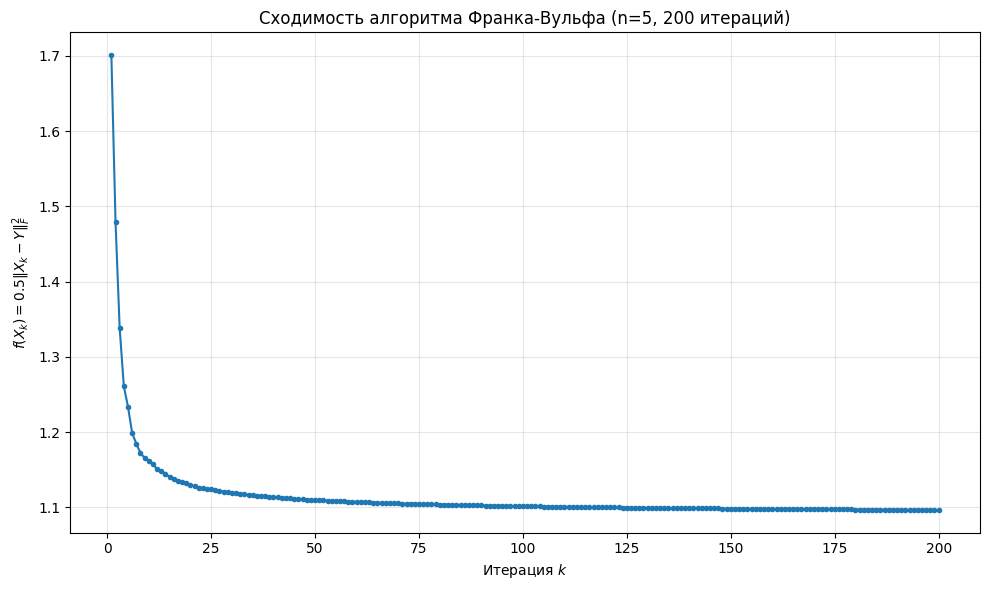


Финальная матрица X_200 (проекция на многогранник Биркгофа):
[[0.19291123 0.4102764  0.14172952 0.24922157 0.00586128]
 [0.00586128 0.00586128 0.28879682 0.26941199 0.43006864]
 [0.00586128 0.56924755 0.3842044  0.00935743 0.03132935]
 [0.24346055 0.00875349 0.17940799 0.32687106 0.24150692]
 [0.55190566 0.00586128 0.00586128 0.14513796 0.29123382]]

Минимальный элемент матрицы: 5.86e-03
Все элементы неотрицательны

Суммы по строкам: [1. 1. 1. 1. 1.]
Отклонение от 1 (макс.): 4.44e-16

Суммы по столбцам: [1. 1. 1. 1. 1.]
Отклонение от 1 (макс.): 2.22e-16


In [5]:
np.random.seed(42)
n = 5
Y = np.random.rand(n, n)

print("Исходная матрица Y (5×5):")
print(Y)
print()

X_final, obj_history = project_to_birkhoff_frank_wolfe(
    Y, max_iter=200, tol=1e-8
)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(obj_history) + 1), obj_history, marker='o', markersize=3)
plt.xlabel('Итерация $k$')
plt.ylabel('$f(X_k) = 0.5 \|X_k - Y\|_F^2$')
plt.title('Сходимость алгоритма Франка‑Вульфа (n=5, 200 итераций)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nФинальная матрица X_200 (проекция на многогранник Биркгофа):")
print(X_final)
print()

min_entry = np.min(X_final)
print(f"Минимальный элемент матрицы: {min_entry:.2e}")
if min_entry >= 0:
    print("Все элементы неотрицательны")
else:
    print("Есть отрицательные элементы")

row_sums = X_final.sum(axis=1)
print(f"\nСуммы по строкам: {row_sums}")
print(f"Отклонение от 1 (макс.): {np.max(np.abs(row_sums - 1)):.2e}")

col_sums = X_final.sum(axis=0)
print(f"\nСуммы по столбцам: {col_sums}")
print(f"Отклонение от 1 (макс.): {np.max(np.abs(col_sums - 1)):.2e}")

# Итоговая оценка выполнения условий
tolerance = 1e-5
rows_ok = np.allclose(row_sums, 1, atol=tolerance)
cols_ok = np.allclose(col_sums, 1, atol=tolerance)
nonneg_ok = min_entry >= -tolerance  # допускаем отрицательные значения из‑за ошибок округления